Step 1: Download from Pink Sheet URL

In [2]:
import pandas as pd
import requests
import io

# Updated URL — World Bank Pink Sheet 2025 (hash updated annually)
PINK_SHEET_URL = "https://thedocs.worldbank.org/en/doc/74e8be41ceb20fa0da750cda2f6b9e4e-0050012026/related/CMO-Historical-Data-Monthly.xlsx"

response = requests.get(PINK_SHEET_URL)
print("Status code:", response.status_code)
print("Content-Type:", response.headers.get("Content-Type"))
print("File size:", len(response.content), "bytes")

Status code: 200
Content-Type: application/vnd.openxmlformats-officedocument.spreadsheetml.sheet
File size: 588324 bytes


Step 2: Check what sheets are available in that URL (want Monthly Prices)

In [3]:
# Check what sheets are available
import openpyxl
wb_file = openpyxl.load_workbook(io.BytesIO(response.content), read_only=True)
print("Sheet names:", wb_file.sheetnames)

Sheet names: ['AFOSHEET', 'Monthly Prices', 'Monthly Indices', 'Description', 'Index Weights']


Step 3: Load to df without skiprows and check shape and head to understand the whole dataset

In [4]:
# Load the Excel file into a pandas DataFrame
# The prices are on the "Monthly Prices" sheet
df_raw = pd.read_excel(
    io.BytesIO(response.content),
    sheet_name="Monthly Prices",
    header= None # dont assume anything about the header yet
)

print("Shape", df_raw.shape)
print("Columns (first 20):", df_raw.columns.tolist()[:20])
df_raw.head(10)

Shape (803, 72)
Columns (first 20): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


,0,1,2,3,4,5,6,7,8,9,...,62,63,64,65,66,67,68,69,70,71
0,World Bank Commodity Price Data (The Pink Sheet),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"monthly prices in nominal US dollars, 1960 to ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,(monthly series are available only in nominal ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Updated on June 02, 2026",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,"Crude oil, average","Crude oil, Brent","Crude oil, Dubai","Crude oil, WTI","Coal, Australian","Coal, South African **","Natural gas, US","Natural gas, Europe","Liquefied natural gas, Japan",...,Aluminum,"Iron ore, cfr spot",Copper,Lead,Tin,Nickel,Zinc,Gold,Platinum,Silver
5,NaN,($/bbl),($/bbl),($/bbl),($/bbl),($/mt),($/mt),($/mmbtu),($/mmbtu),($/mmbtu),...,($/mt),($/dmtu),($/mt),($/mt),($/mt),($/mt),($/mt),($/troy oz),($/troy oz),($/troy oz)
6,1960M01,1.63,1.63,1.63,…,…,…,0.14,0.4,…,...,511.47,11.42,715.4,206.1,2180.4,1631,260.8,35.27,83.5,0.91
7,1960M02,1.63,1.63,1.63,…,…,…,0.14,0.4,…,...,511.47,11.42,728.19,203.7,2180.4,1631,244.9,35.27,83.5,0.91
8,1960M03,1.63,1.63,1.63,…,…,…,0.14,0.4,…,...,511.47,11.42,684.94,210.3,2173.8,1631,248.7,35.27,83.5,0.91
9,1960M04,1.63,1.63,1.63,…,…,…,0.14,0.4,…,...,511.47,11.42,723.11,213.6,2178.2,1631,254.6,35.27,83.5,0.91


In [5]:
df_raw.iloc[0:8, 0:10]   # first 8 rows, first 10 columns

,0,1,2,3,4,5,6,7,8,9
0,World Bank Commodity Price Data (The Pink Sheet),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"monthly prices in nominal US dollars, 1960 to ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,(monthly series are available only in nominal ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Updated on June 02, 2026",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,"Crude oil, average","Crude oil, Brent","Crude oil, Dubai","Crude oil, WTI","Coal, Australian","Coal, South African **","Natural gas, US","Natural gas, Europe","Liquefied natural gas, Japan"
5,NaN,($/bbl),($/bbl),($/bbl),($/bbl),($/mt),($/mt),($/mmbtu),($/mmbtu),($/mmbtu)
6,1960M01,1.63,1.63,1.63,…,…,…,0.14,0.4,…
7,1960M02,1.63,1.63,1.63,…,…,…,0.14,0.4,…


Step 4: Load with correct skiprows

In [6]:
df = pd.read_excel(
    io.BytesIO(response.content),
    sheet_name="Monthly Prices",
    skiprows=4 # skip row 0-3, row 4 become the header
)

# Row 0 in df is now the the units row — drop it and reset the index
df = df.drop(index=0).reset_index(drop=True)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (797, 72)
Columns: ['Unnamed: 0', 'Crude oil, average', 'Crude oil, Brent', 'Crude oil, Dubai', 'Crude oil, WTI', 'Coal, Australian', 'Coal, South African **', 'Natural gas, US', 'Natural gas, Europe', 'Liquefied natural gas, Japan', 'Natural gas index', 'Cocoa', 'Coffee, Arabica', 'Coffee, Robusta', 'Tea, avg 3 auctions', 'Tea, Colombo', 'Tea, Kolkata', 'Tea, Mombasa', 'Coconut oil', 'Groundnuts', 'Fish meal', 'Groundnut oil **', 'Palm oil', 'Palm kernel oil', 'Soybeans', 'Soybean oil', 'Soybean meal', 'Rapeseed oil', 'Sunflower oil', 'Barley', 'Maize', 'Sorghum', 'Rice, Thai 5% ', 'Rice, Thai 25% ', 'Rice, Thai A.1', 'Rice, Viet Namese 5%', 'Wheat, US SRW', 'Wheat, US HRW', 'Banana, Europe', 'Banana, US', 'Orange', 'Beef **', 'Chicken **', 'Lamb **', 'Shrimps, Mexican', 'Sugar, EU', 'Sugar, US', 'Sugar, world', 'Tobacco, US import u.v.', 'Logs, Cameroon', 'Logs, Malaysian', 'Sawnwood, Cameroon', 'Sawnwood, Malaysian', 'Plywood', 'Cotton, A Index', 'Rubber, TSR20 **', 'Rubber, 

,Unnamed: 0,"Crude oil, average","Crude oil, Brent","Crude oil, Dubai","Crude oil, WTI","Coal, Australian","Coal, South African **","Natural gas, US","Natural gas, Europe","Liquefied natural gas, Japan",...,Aluminum,"Iron ore, cfr spot",Copper,Lead,Tin,Nickel,Zinc,Gold,Platinum,Silver
0,1960M01,1.63,1.63,1.63,…,…,…,0.14,0.4,…,...,511.47,11.42,715.4,206.1,2180.4,1631,260.8,35.27,83.5,0.91
1,1960M02,1.63,1.63,1.63,…,…,…,0.14,0.4,…,...,511.47,11.42,728.19,203.7,2180.4,1631,244.9,35.27,83.5,0.91
2,1960M03,1.63,1.63,1.63,…,…,…,0.14,0.4,…,...,511.47,11.42,684.94,210.3,2173.8,1631,248.7,35.27,83.5,0.91
3,1960M04,1.63,1.63,1.63,…,…,…,0.14,0.4,…,...,511.47,11.42,723.11,213.6,2178.2,1631,254.6,35.27,83.5,0.91
4,1960M05,1.63,1.63,1.63,…,…,…,0.14,0.4,…,...,511.47,11.42,684.75,213.4,2162.7,1631,253.8,35.27,83.5,0.91


Step 5: Find exactly which columns are our 4 oils

In [7]:
oil_cols = [col for col in df.columns if any(
    keyword in str(col).lower()
    for keyword in ["palm", "soybean", "rapeseed", "sunflower", "canola"]
)]

print("Oil Columns:", oil_cols)

Oil Columns: ['Palm oil', 'Palm kernel oil', 'Soybeans', 'Soybean oil', 'Soybean meal', 'Rapeseed oil', 'Sunflower oil']


Step 6: Extract just what we need

In [8]:
# Column 0 is the date column — check what it's called
print("First column name:", df.columns[0])
print("First column sample:", df.iloc[:3, 0].tolist())

First column name: Unnamed: 0
First column sample: ['1960M01', '1960M02', '1960M03']


Step 7: Extract and rename

In [9]:
# Exact column names confirmed from the Excel
COLUMN_MAP = {
    "Unnamed: 0":   "month_date",
    "Palm oil":     "cpo_price",
    "Soybean oil":  "soyoil_price",
    "Sunflower oil":"sunflower_price",
    "Rapeseed oil": "rapeseed_price"
}

# Select only the columns we need, rename them
df_oils = df[list(COLUMN_MAP.keys())].rename(columns=COLUMN_MAP).copy()

print("Shape:", df_oils.shape)
df_oils.head(3)

Shape: (797, 5)


,month_date,cpo_price,soyoil_price,sunflower_price,rapeseed_price
0,1960M01,233,204,…,…
1,1960M02,229,201,…,…
2,1960M03,225,201,…,…


Step 8: Fix the date column

In [10]:
df_oils["month_date"] = pd.to_datetime(df_oils["month_date"], format="%YM%m")
df_oils = df_oils[df_oils["month_date"] >= "2015-01-01"].reset_index(drop=True)

print("Date range:", df_oils["month_date"].min(), "to", df_oils["month_date"].max())
print("Shape after filter:", df_oils.shape)
df_oils.head(10)

Date range: 2015-01-01 00:00:00 to 2026-05-01 00:00:00
Shape after filter: (137, 5)


,month_date,cpo_price,soyoil_price,sunflower_price,rapeseed_price
0,2015-01-01,719.64,796.58,870.71,777.72
1,2015-02-01,723.04,762.61,825,762.51
2,2015-03-01,698.86,749.93,804.55,751.16
3,2015-04-01,682.75,747.74,833.5,747.72
4,2015-05-01,697.35,785.13,916.05,769.95
5,2015-06-01,705.91,788.21,927.95,841.79
6,2015-07-01,680,752.32,917.39,809.98
7,2015-08-01,601.38,728.33,894.75,753.56
8,2015-09-01,599.5,720.4,896.82,771.69
9,2015-10-01,636.67,743.3,961.59,809.13


Step 9: Handle the ... placeholder values

In [11]:
# The Excel uses "…" for missing data — convert to NaN, then to float
for col in ["cpo_price", "soyoil_price", "sunflower_price", "rapeseed_price"]:
    df_oils[col] = pd.to_numeric(df_oils[col], errors="coerce")

print("Dtypes:\n", df_oils.dtypes)
print("\nNull counts:\n", df_oils.isnull().sum())

Dtypes:
 month_date         datetime64[us]
cpo_price                 float64
soyoil_price              float64
sunflower_price           float64
rapeseed_price            float64
dtype: object

Null counts:
 month_date         0
cpo_price          0
soyoil_price       0
sunflower_price    0
rapeseed_price     0
dtype: int64


Step 10: Data quality check

In [12]:
print(df_oils.describe())

                       month_date    cpo_price  soyoil_price  sunflower_price  \
count                         137   137.000000    137.000000       137.000000   
mean   2020-08-31 04:22:46.423357   863.498102   1029.882920      1047.434453   
min           2015-01-01 00:00:00   535.020000    679.980000       688.130000   
25%           2017-11-01 00:00:00   694.160000    788.570000       806.000000   
50%           2020-09-01 00:00:00   811.380000    911.900000       917.390000   
75%           2023-07-01 00:00:00  1004.420000   1145.170000      1233.800000   
max           2026-05-01 00:00:00  1776.960000   1962.880000      2361.130000   
std                           NaN   243.326853    306.377726       316.217101   

       rapeseed_price  
count      137.000000  
mean      1075.393358  
min        747.720000  
25%        840.010000  
50%        945.390000  
75%       1241.140000  
max       2266.170000  
std        326.055565  


Step 11: Quick plot to sanity check

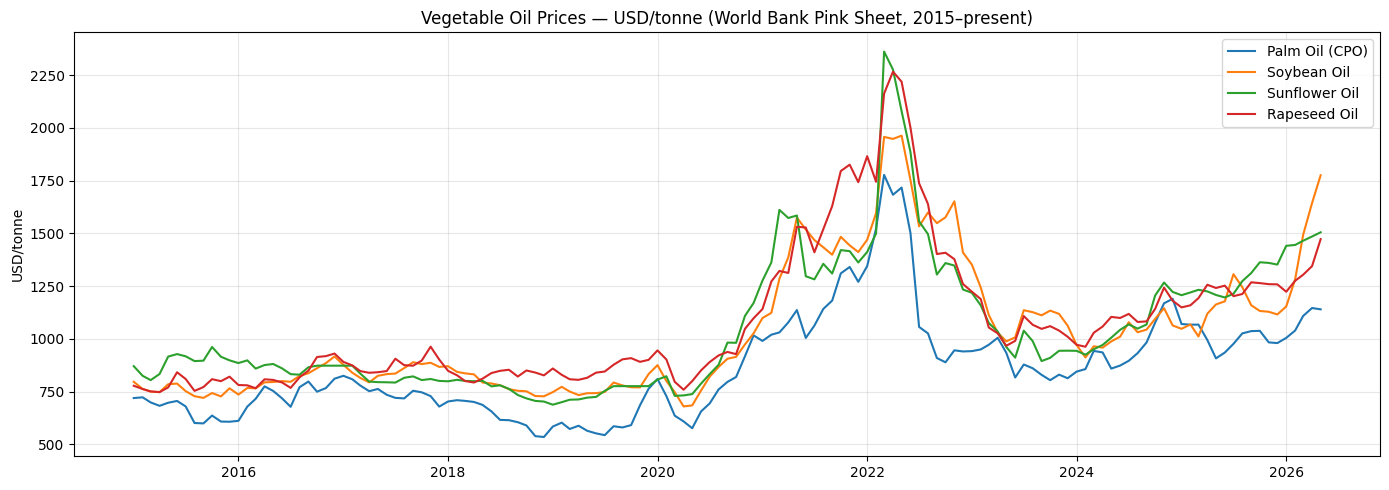

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

for col, label in [
    ("cpo_price",       "Palm Oil (CPO)"),
    ("soyoil_price",    "Soybean Oil"),
    ("sunflower_price", "Sunflower Oil"),
    ("rapeseed_price",  "Rapeseed Oil"),
]:
    ax.plot(df_oils["month_date"], df_oils[col], label=label)

ax.set_title("Vegetable Oil Prices — USD/tonne (World Bank Pink Sheet, 2015–present)")
ax.set_ylabel("USD/tonne")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Notebook 01 — Findings & Decisions

**Source:** World Bank Pink Sheet (CMO-Historical-Data-Monthly.xlsx)
**Date range confirmed:** 2015-01-01 → 2026-04-01
**Shape:** 136 rows × 5 columns (after filter to 2015)
**Null values:** None
**Units:** All four oils in USD/tonne ✓

**Columns for pipeline:**
- month_date (datetime, first of month)
- cpo_price
- soyoil_price
- sunflower_price
- rapeseed_price

**Why CPO not PKO:** PKO serves personal care markets, not edible oil/biodiesel.
CPO is the correct benchmark for substitution spread analysis.

**Key observation:** Sunflower oil spiked highest in 2022 (Russia-Ukraine war
disrupted Black Sea exports). CPO spiked later and less severely — confirms
CPO's role as a substitute that absorbed demand during the crisis.

**Data lag:** ~1 month. File updated monthly, but always reflects previous month.
Example: May 2026 update contains data through April 2026.

**URL maintenance — action required once per year (~January):**
The Pink Sheet URL hash changes once per year. Same URL works all year long.
Current URL (valid entire 2026): 
https://thedocs.worldbank.org/en/doc/74e8be41ceb20fa0da750cda2f6b9e4e-0050012026/related/CMO-Historical-Data-Monthly.xlsx
To update: go to https://www.worldbank.org/en/research/commodity-markets
→ right-click CMO-Historical-Data-Monthly.xlsx → Copy link address
→ replace URL in this notebook and in src/extract_worldbank.py

In [14]:
df_oils.to_csv("nb01_wb_prices_clean.csv", index=False)
print("Saved:", df_oils.shape)
print(df_oils.head(3))

Saved: (137, 5)
  month_date  cpo_price  soyoil_price  sunflower_price  rapeseed_price
0 2015-01-01     719.64        796.58           870.71          777.72
1 2015-02-01     723.04        762.61           825.00          762.51
2 2015-03-01     698.86        749.93           804.55          751.16
